# Homophily Analysis & Cross-Platform Comparison
This notebook measures homophily in the Hantavirus reply network, and compares findings across YouTube and Bluesky.

---
### Import Libraries

In [1]:
# Run this cell if nrclex is not already installed
# !pip install nrclex

In [2]:
#Import all required libraries
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ast
import re
import string
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from collections import Counter

nltk.download('vader_lexicon', quiet=True)
nltk.download('stopwords',    quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import TweetTokenizer

---
### Load Data

In [3]:
#Load the Bluesky dataset
bsDF = pd.read_csv('Data/Bluesky_dataset_UG11.csv')

print("Bluesky posts:", len(bsDF))
print("Unique authors:", bsDF['author'].nunique())

Bluesky posts: 14451
Unique authors: 8655


In [4]:
#View the data to ensure it has been correctly imported
bsDF.head()

,uri,author,replying_to,text,created_at,depth,likes,reposts,period
0,at://did:plc:zxh6uh5wehlxl3mmos7bz372/app.bsky...,yourcanadiangf.bsky.social,robdelaney.bsky.social,did he do Elon's botched Dong implant?,2026-05-15T16:15:34.751Z,1,0,0,NaN
1,at://did:plc:zwxw7hwlxh6exd7mo3wbqvos/app.bsky...,fluffythecruel.bsky.social,robdelaney.bsky.social,I’m at the penile implant specialist. I’m at t...,2026-05-15T11:08:07.165Z,1,3,0,NaN
2,at://did:plc:zqgf4oiy74m2exchgf4vjbyb/app.bsky...,marcosantana.bsky.social,robdelaney.bsky.social,A twofer,2026-05-15T12:44:58.919Z,1,0,0,NaN
3,at://did:plc:zqgf4oiy74m2exchgf4vjbyb/app.bsky...,marcosantana.bsky.social,robdelaney.bsky.social,A twofer.,2026-05-15T12:44:00.948Z,1,0,0,NaN
4,at://did:plc:zq4y36m255l4tbsvef4yblsk/app.bsky...,twinsfan81.bsky.social,robdelaney.bsky.social,"They are trying to kill all of us, aren’t they.",2026-05-15T14:15:38.513Z,1,1,0,NaN


In [5]:
#Load the YouTube comments with sentiment already computed
ytDF = pd.read_csv('Data/youtube_comments_final_analysis.csv')

print("YouTube comments:", len(ytDF))

YouTube comments: 9668


In [6]:
#Load the Hantavirus reply network
sFileName = "Graphs/UG11_communities.graphml"
G = nx.read_graphml(sFileName)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 8755
Edges: 10883


---
### Bluesky Sentiment Analysis

In [7]:
#Initialise VADER sentiment analyser
sentAnalyser = SentimentIntensityAnalyzer()

#Helper function to classify compound score into a label
#Using standard VADER thresholds
def classifySentiment(score):
    if score > 0.05:  return 'positive'
    if score < -0.05: return 'negative'
    return 'neutral'

In [8]:
#Apply VADER to every Bluesky post
bsDF['compound']       = bsDF['text'].apply(lambda t: sentAnalyser.polarity_scores(str(t))['compound'])
bsDF['sentimentLabel'] = bsDF['compound'].apply(classifySentiment)

#Output sentiment distribution
bsDF['sentimentLabel'].value_counts()

sentimentLabel
negative    5323
positive    4926
neutral     4202
Name: count, dtype: int64

In [9]:
#Compute sentiment distribution counts and percentages
labelCounts = bsDF['sentimentLabel'].value_counts()
labels = ['positive', 'neutral', 'negative']
values = [labelCounts.get(l, 0) for l in labels]

print('Bluesky sentiment distribution:')
for l, v in zip(labels, values):
    print('  {}: {:,} posts ({:.1f}%)'.format(l, v, v/sum(values)*100))

Bluesky sentiment distribution:
  positive: 4,926 posts (34.1%)
  neutral: 4,202 posts (29.1%)
  negative: 5,323 posts (36.8%)


---
### Aggregate Sentiment Per User

In [10]:
#Network nodes are users
#Aggregate to get one sentiment value per user
#Mean compound score across all their posts
userCompound = bsDF.groupby('author')['compound'].mean().to_dict()

#Majority sentiment label across all their posts
userLabel = (
    bsDF.groupby('author')['sentimentLabel']
    .agg(lambda x: x.value_counts().index[0])
    .to_dict()
)

print("Users with computed sentiment:", len(userCompound))

Users with computed sentiment: 8655


In [11]:
#Output user-level sentiment breakdown
Counter(userLabel.values())

Counter({'negative': 3183, 'positive': 2834, 'neutral': 2638})

---
### Add Sentiment Attributes to Graph Nodes

In [12]:
#Attach sentiment_label and sentiment_compound to each node in the reply graph
#Nodes with no Bluesky posts in our dataset are assigned a neutral default
matched = 0
for node in G.nodes():
    if node in userCompound:
        G.nodes[node]['sentimentCompound'] = float(userCompound[node])
        G.nodes[node]['sentimentLabel']    = userLabel[node]
        matched += 1
    else:
        #Default to neutral for users not in our dataset
        G.nodes[node]['sentimentCompound'] = 0.0
        G.nodes[node]['sentimentLabel']    = 'neutral'

print("Nodes matched to Bluesky data: {}/{}".format(matched, G.number_of_nodes()))

Nodes matched to Bluesky data: 8655/8755


In [13]:
#Save the enriched graph 
nx.write_graphml(G, 'Graphs/HV_sentiment_graph.graphml')

---
### Homophily Analysis

In [14]:
#Sentiment label assortativity
#Do users with the same sentiment label tend to reply to each other?
rSentimentLabel = nx.attribute_assortativity_coefficient(G, 'sentimentLabel')

#Sentiment compound assortativity 
#Do users with similar compound scores connect?
rSentimentCompound = nx.numeric_assortativity_coefficient(G, 'sentimentCompound')

#Community assortativity 
#Do users stay within their Louvain community?
rCommunity = nx.attribute_assortativity_coefficient(G, 'louvain')

#Katz centrality assortativity 
#Do high-influence users connect to other high-influence users?
rKatz = nx.numeric_assortativity_coefficient(G, 'katz')

print("Sentiment label assortativity    (r): {:.4f}".format(rSentimentLabel))
print("Sentiment compound assortativity (r): {:.4f}".format(rSentimentCompound))
print("Community (Louvain) assortativity(r): {:.4f}".format(rCommunity))
print("Katz centrality assortativity    (r): {:.4f}".format(rKatz))

Sentiment label assortativity    (r): 0.0485
Sentiment compound assortativity (r): 0.0673
Community (Louvain) assortativity(r): 0.8897
Katz centrality assortativity    (r): -0.1079


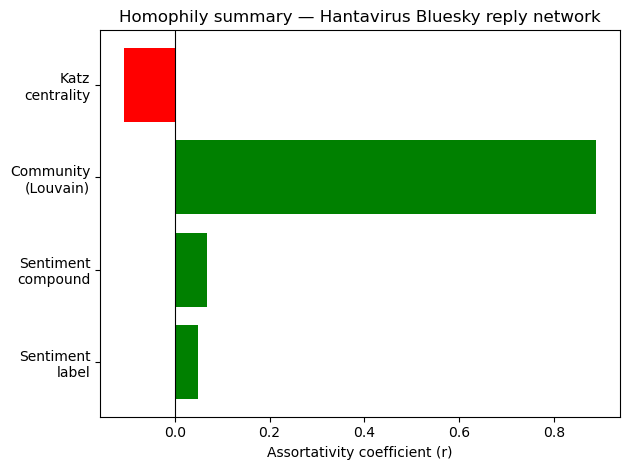

In [15]:
#Plot a summary bar chart of all assortativity measures
measures = ['Sentiment\nlabel', 'Sentiment\ncompound', 'Community\n(Louvain)', 'Katz\ncentrality']
rValues  = [rSentimentLabel, rSentimentCompound, rCommunity, rKatz]
colours  = ['green' if r >= 0 else 'red' for r in rValues]

plt.barh(measures, rValues, color=colours)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Assortativity coefficient (r)')
plt.title('Homophily summary — Hantavirus Bluesky reply network')
plt.tight_layout()
plt.show()

---
#### Sentiment Mixing Matrix

In [16]:
#Build a mixing matrix to show how often each sentiment group connects to the other
labelOrder = ['positive', 'neutral', 'negative']
mixMatrix  = pd.DataFrame(0, index=labelOrder, columns=labelOrder)

for u, v in G.edges():
    lu = G.nodes[u].get('sentimentLabel', 'neutral')
    lv = G.nodes[v].get('sentimentLabel', 'neutral')
    mixMatrix.loc[lu, lv] += 1
    mixMatrix.loc[lv, lu] += 1

#Normalise by row to get proportions
mixMatrixPct = mixMatrix.div(mixMatrix.sum(axis=1), axis=0).mul(100).round(1)

#Output the mixing matrix
mixMatrixPct

,positive,neutral,negative
positive,39.7,25.9,34.4
neutral,33.8,32.0,34.2
negative,35.2,26.8,38.0


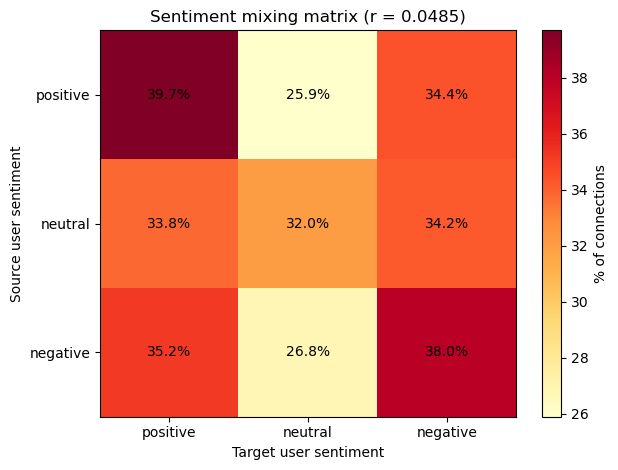

In [17]:
#Plot the mixing matrix as a heatmap
plt.imshow(mixMatrixPct.values, cmap='YlOrRd', aspect='auto')
plt.xticks(range(len(labelOrder)), labelOrder)
plt.yticks(range(len(labelOrder)), labelOrder)
plt.xlabel('Target user sentiment')
plt.ylabel('Source user sentiment')
plt.title('Sentiment mixing matrix (r = {:.4f})'.format(rSentimentLabel))
plt.colorbar(label='% of connections')

#Annotate cells with percentages
for i in range(len(labelOrder)):
    for j in range(len(labelOrder)):
        plt.text(j, i, '{}%'.format(mixMatrixPct.values[i, j]),
                 ha='center', va='center', fontsize=10)

plt.tight_layout()
plt.show()

---
#### Community Sentiment Breakdown

In [18]:
#Build a dataframe of community membership and sentiment for each node
commRows = [(G.nodes[n]['louvain'], G.nodes[n]['sentimentLabel']) for n in G.nodes()]
commDF   = pd.DataFrame(commRows, columns=['community', 'sentiment'])

#Filter to communities with at least 50 members and take top 10 by size
commSizes = commDF['community'].value_counts()
topComms  = commSizes[commSizes >= 50].index.tolist()[:10]

#Compute sentiment proportions per community
topCommDF   = commDF[commDF['community'].isin(topComms)]
commPivot   = topCommDF.groupby(['community', 'sentiment']).size().unstack(fill_value=0)
commPivotPct = commPivot.div(commPivot.sum(axis=1), axis=0).mul(100)

#Sort by community size
commPivotPct = commPivotPct.loc[commSizes[topComms].sort_values(ascending=False).index]

commPivotPct

sentiment,negative,neutral,positive
community,,,
7,34.194831,29.423459,36.381710
31,36.094675,30.769231,33.136095
57,36.615385,27.384615,36.000000
35,40.000000,29.354839,30.645161
10,32.404181,35.888502,31.707317
1,42.142857,24.285714,33.571429
62,29.779412,28.308824,41.911765
40,37.246964,27.125506,35.627530
43,40.573770,25.000000,34.426230


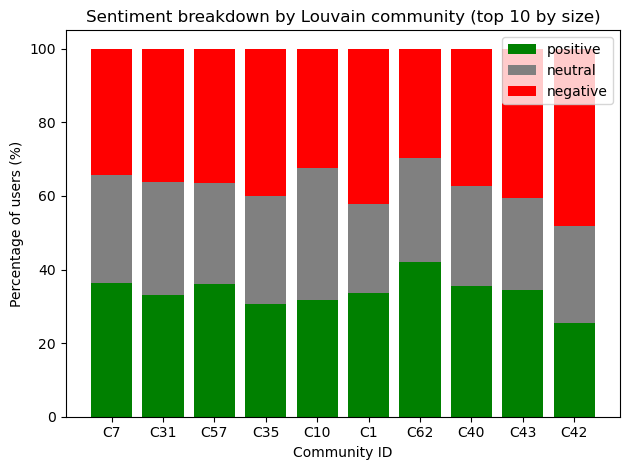

In [19]:
#Plot stacked bar chart of sentiment breakdown per community
bottom = np.zeros(len(commPivotPct))
colours = {'positive': 'green', 'neutral': 'grey', 'negative': 'red'}
xLabels = ['C{}'.format(c) for c in commPivotPct.index]

for sentiment in ['positive', 'neutral', 'negative']:
    if sentiment in commPivotPct.columns:
        vals = commPivotPct[sentiment].values
        plt.bar(xLabels, vals, bottom=bottom, label=sentiment, color=colours[sentiment])
        bottom += vals

plt.title('Sentiment breakdown by Louvain community (top 10 by size)')
plt.xlabel('Community ID')
plt.ylabel('Percentage of users (%)')
plt.legend()
plt.tight_layout()
plt.show()

---
#### Katz Centrality Scatter

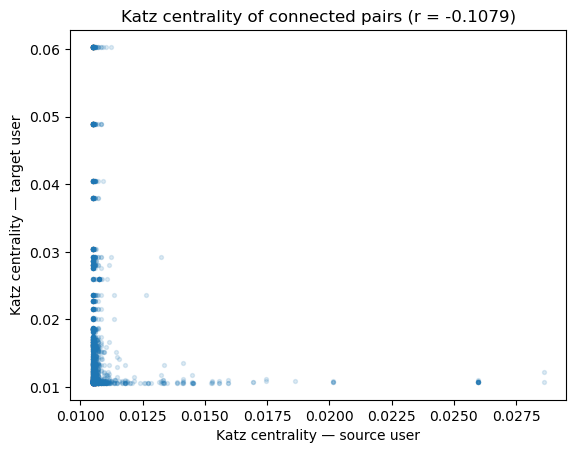

In [20]:
#Scatter plot of Katz centrality for connected pairs
import random
random.seed(42)

#Sample 2000 edges for readability
edgeSample = random.sample(list(G.edges()), min(2000, G.number_of_edges()))

katzU = [G.nodes[u].get('katz', 0) for u, v in edgeSample]
katzV = [G.nodes[v].get('katz', 0) for u, v in edgeSample]

plt.scatter(katzU, katzV, alpha=0.15, s=8)
plt.xlabel('Katz centrality — source user')
plt.ylabel('Katz centrality — target user')
plt.title('Katz centrality of connected pairs (r = {:.4f})'.format(rKatz))
plt.show()

---
### Cross-Platform Sentiment Comparison: YouTube vs Bluesky

In [21]:
#Compute sentiment proportions for each platform
labelsOrder = ['positive', 'neutral', 'negative']

ytPcts = ytDF['vader_label'].value_counts(normalize=True).mul(100)
bsPcts = bsDF['sentimentLabel'].value_counts(normalize=True).mul(100)

ytMean = ytDF['compound'].mean()
bsMean = bsDF['compound'].mean()

print("Platform    | Positive | Neutral  | Negative | Mean compound")
print("-" * 60)
print("YouTube     | {:6.1f}%  | {:6.1f}%  | {:6.1f}%  | {:+.4f}".format(
    ytPcts.get('positive', 0), ytPcts.get('neutral', 0), ytPcts.get('negative', 0), ytMean))
print("Bluesky     | {:6.1f}%  | {:6.1f}%  | {:6.1f}%  | {:+.4f}".format(
    bsPcts.get('positive', 0), bsPcts.get('neutral', 0), bsPcts.get('negative', 0), bsMean))

Platform    | Positive | Neutral  | Negative | Mean compound
------------------------------------------------------------
YouTube     |   34.2%  |   30.6%  |   35.3%  | -0.0150
Bluesky     |   34.1%  |   29.1%  |   36.8%  | -0.0216


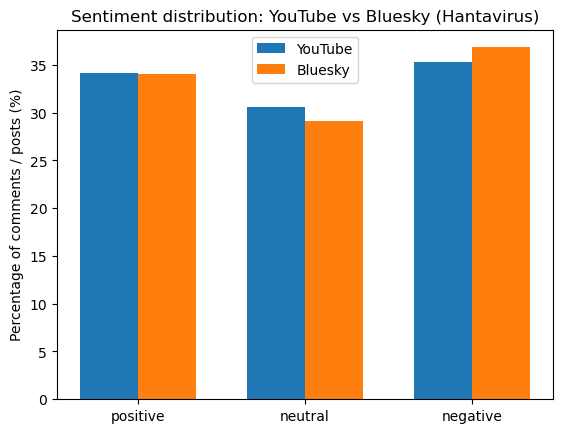

In [22]:
#Plot grouped bar chart comparing sentiment proportions across platforms
x     = np.arange(len(labelsOrder))
width = 0.35

ytVals = [ytPcts.get(l, 0) for l in labelsOrder]
bsVals = [bsPcts.get(l, 0) for l in labelsOrder]

plt.bar(x - width/2, ytVals, width, label='YouTube')
plt.bar(x + width/2, bsVals, width, label='Bluesky')
plt.xticks(x, labelsOrder)
plt.ylabel('Percentage of comments / posts (%)')
plt.title('Sentiment distribution: YouTube vs Bluesky (Hantavirus)')
plt.legend()
plt.show()

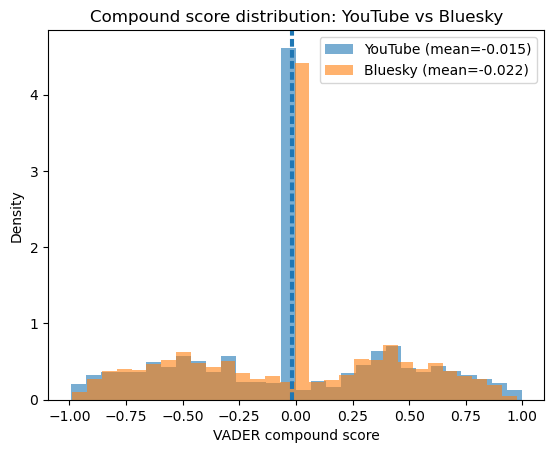

In [23]:
#Plot compound score distributions for both platforms
plt.hist(ytDF['compound'], bins=30, alpha=0.6, label='YouTube (mean={:+.3f})'.format(ytMean), density=True)
plt.hist(bsDF['compound'], bins=30, alpha=0.6, label='Bluesky (mean={:+.3f})'.format(bsMean), density=True)
plt.axvline(ytMean, linestyle='--', linewidth=1.5)
plt.axvline(bsMean, linestyle='--', linewidth=1.5)
plt.xlabel('VADER compound score')
plt.ylabel('Density')
plt.title('Compound score distribution: YouTube vs Bluesky')
plt.legend()
plt.show()

---
#### Polarisation Comparison

Polarity breakdown (%):
Category                  YouTube    Bluesky
Strongly positive           15.3%      14.5%
Moderate                    66.4%      67.3%
Strongly negative           18.3%      18.2%


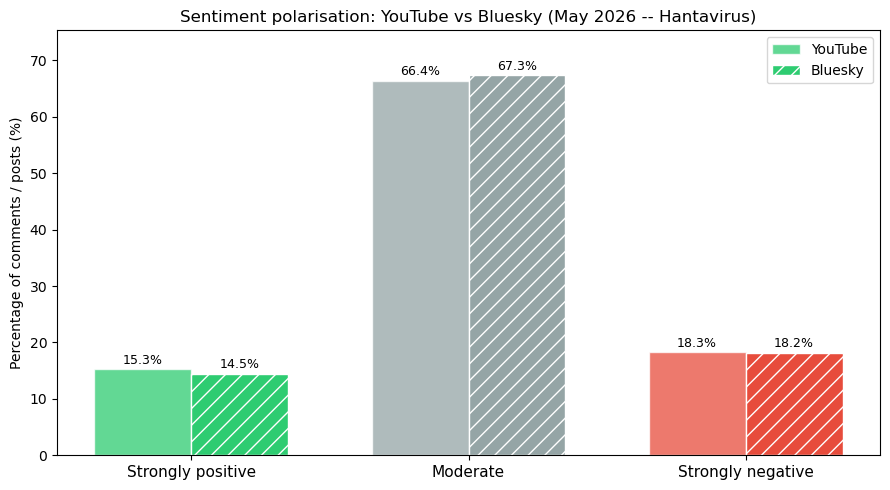

In [24]:
#Proportion of strongly positive vs strongly negative comments per platform
#Uses compound thresholds: strongly positive >0.5, strongly negative <-0.5, moderate in between
#Both datasets restricted to May 2026 comments to match the same outbreak window
#Filter YouTube to 2026 comments 
ytDF['commentPublishedAt'] = pd.to_datetime(ytDF['commentPublishedAt'], utc=True)
ytMay = ytDF[ytDF['commentPublishedAt'].dt.year == 2026].copy()

#Classify each comment/post into three polarity bins
def polarityBin(compound):
    if compound > 0.5:  return 'Strongly positive'
    if compound < -0.5: return 'Strongly negative'
    return 'Moderate'

ytMay['polarity'] = ytMay['compound'].apply(polarityBin)
bsDF['polarity']  = bsDF['compound'].apply(polarityBin)

#Compute percentages for each bin
polarityOrder = ['Strongly positive', 'Moderate', 'Strongly negative']
ytPol = ytMay['polarity'].value_counts(normalize=True).mul(100).reindex(polarityOrder, fill_value=0)
bsPol = bsDF['polarity'].value_counts(normalize=True).mul(100).reindex(polarityOrder, fill_value=0)

print('Polarity breakdown (%):')
print('{:<22} {:>10} {:>10}'.format('Category', 'YouTube', 'Bluesky'))
for cat in polarityOrder:
    print('{:<22} {:>9.1f}% {:>9.1f}%'.format(cat, ytPol[cat], bsPol[cat]))

#Grouped bar chart
x     = np.arange(len(polarityOrder))
width = 0.35
polColours = {'Strongly positive': '#2ecc71', 'Moderate': '#95a5a6', 'Strongly negative': '#e74c3c'}
colours    = [polColours[c] for c in polarityOrder]

fig, ax = plt.subplots(figsize=(9, 5))
barsYT = ax.bar(x - width/2, [ytPol[c] for c in polarityOrder], width,
                label='YouTube', color=colours, alpha=0.75, edgecolor='white')
barsBS = ax.bar(x + width/2, [bsPol[c] for c in polarityOrder], width,
                label='Bluesky',  color=colours, alpha=1.0,  edgecolor='white', hatch='//')

for bar in list(barsYT) + list(barsBS):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.4,
            '{:.1f}%'.format(h), ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(polarityOrder, fontsize=11)
ax.set_ylabel('Percentage of comments / posts (%)')
ax.set_title('Sentiment polarisation: YouTube vs Bluesky (May 2026 -- Hantavirus)')
ax.legend()
ax.set_ylim(0, max(ytPol.max(), bsPol.max()) + 8)
plt.tight_layout()
plt.savefig('images/polarisation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
#### Engagement vs Sentiment

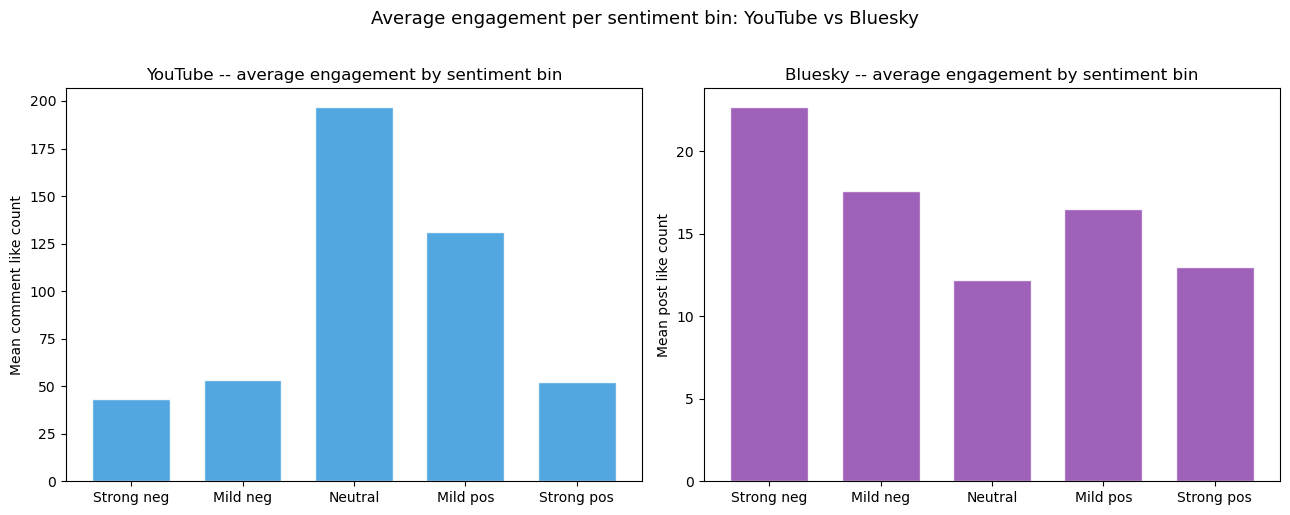

YouTube mean likes by bin:
compBin
Strong neg     43.50
Mild neg       53.27
Neutral       196.82
Mild pos      130.95
Strong pos     52.01

Bluesky mean likes by bin:
compBin
Strong neg    22.69
Mild neg      17.62
Neutral       12.19
Mild pos      16.50
Strong pos    12.98


In [25]:
#Average likes per compound score bin
bins   = [-1.0, -0.5, -0.05, 0.05, 0.5, 1.0]
labels = ['Strong neg', 'Mild neg', 'Neutral', 'Mild pos', 'Strong pos']

ytMay['compBin'] = pd.cut(ytMay['compound'], bins=bins, labels=labels)
bsDF['compBin']  = pd.cut(bsDF['compound'],  bins=bins, labels=labels)

ytBinMean = ytMay.groupby('compBin', observed=True)['commentLikeCount'].mean()
bsBinMean = bsDF.groupby('compBin',  observed=True)['likes'].mean()

x     = np.arange(len(labels))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(x, [ytBinMean.get(l, 0) for l in labels], width*2,
            color='#3498db', alpha=0.85, edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=10)
axes[0].set_ylabel('Mean comment like count')
axes[0].set_title('YouTube -- average engagement by sentiment bin')

axes[1].bar(x, [bsBinMean.get(l, 0) for l in labels], width*2,
            color='#8e44ad', alpha=0.85, edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, fontsize=10)
axes[1].set_ylabel('Mean post like count')
axes[1].set_title('Bluesky -- average engagement by sentiment bin')

plt.suptitle('Average engagement per sentiment bin: YouTube vs Bluesky', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('images/engagement_binned.png', dpi=150, bbox_inches='tight')
plt.show()

print('YouTube mean likes by bin:')
print(ytBinMean.round(2).to_string())
print('\nBluesky mean likes by bin:')
print(bsBinMean.round(2).to_string())

---
#### Keyword Framing

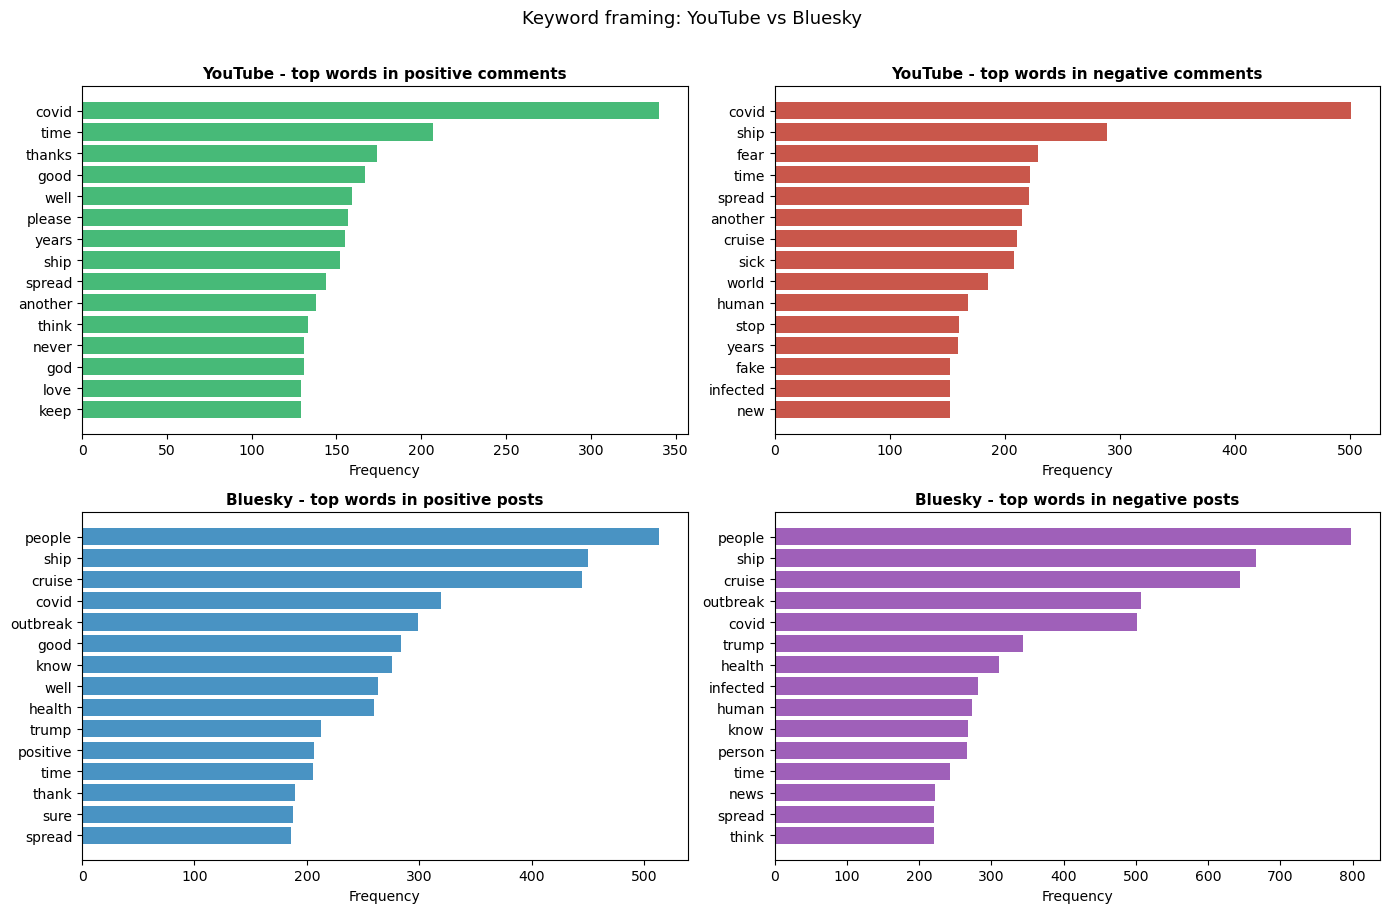

In [26]:
#Which words appear most in positive vs negative content on each platform?
#Reveals whether platforms frame the hantavirus differently
domainStop = {'hantavirus', 'hanta', 'virus', 'http', 'https', 'co', 'amp',
              'de', 'la', 'el', 'que', 'en', 'es', 'se', 'like', 'just', 'get',
              'rt', 'via', 'one', 'would', 'also', 'could', 'going'}
allStop = set(stopwords.words('english')) | set(string.punctuation) | domainStop

#Tokenise Bluesky text directly 
_bsTok = TweetTokenizer()
def tokeniseBS(text):

    text = re.sub(r'http\S+|www\S+', '', str(text))
    text = re.sub(r'[^\w\s]', ' ', text)
    return [t for t in _bsTok.tokenize(text.lower())
            if t not in allStop and len(t) > 2 and not t.isdigit()]

#YouTube already has pre-tokenised 'tokens' column in the CSV
def flattenYTTokens(tokenSeries):
    tokens = []
    for t in tokenSeries.dropna():
        if isinstance(t, list):
            tokens.extend(t)
        else:
            try:
                parsed = ast.literal_eval(str(t))
                if isinstance(parsed, list):
                    tokens.extend(parsed)
            except Exception:
                tokens.extend(str(t).split())
    return tokens

def topYTWords(df, sentCol, label, topN=15):
    subset = df[df[sentCol] == label]
    tokens = flattenYTTokens(subset['tokens'])
    counts = Counter(t.lower() for t in tokens
                     if t.isalpha() and t.lower() not in allStop and len(t) > 2)
    return counts.most_common(topN)

def topBSWords(df, sentCol, label, topN=15):
    subset = df[df[sentCol] == label]
    tokens = [tok for text in subset['text'].dropna() for tok in tokeniseBS(text)]
    counts = Counter(t for t in tokens if t.isalpha() and t not in allStop and len(t) > 2)
    return counts.most_common(topN)

ytPos = topYTWords(ytMay, 'vader_label',    'positive')
ytNeg = topYTWords(ytMay, 'vader_label',    'negative')
bsPos = topBSWords(bsDF,  'sentimentLabel', 'positive')
bsNeg = topBSWords(bsDF,  'sentimentLabel', 'negative')

def plotHBar(ax, wordCounts, colour, title):
    if not wordCounts:
        return
    words, counts = zip(*wordCounts)
    ax.barh(range(len(words)), counts, color=colour, alpha=0.85)
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel('Frequency')
    ax.set_title(title, fontsize=11, fontweight='bold')

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
plotHBar(axes[0,0], ytPos, '#27ae60', 'YouTube - top words in positive comments')
plotHBar(axes[0,1], ytNeg, '#c0392b', 'YouTube - top words in negative comments')
plotHBar(axes[1,0], bsPos, '#2980b9', 'Bluesky - top words in positive posts')
plotHBar(axes[1,1], bsNeg, '#8e44ad', 'Bluesky - top words in negative posts')

plt.suptitle('Keyword framing: YouTube vs Bluesky ', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('images/keyword_framing.png', dpi=150, bbox_inches='tight')
plt.show()

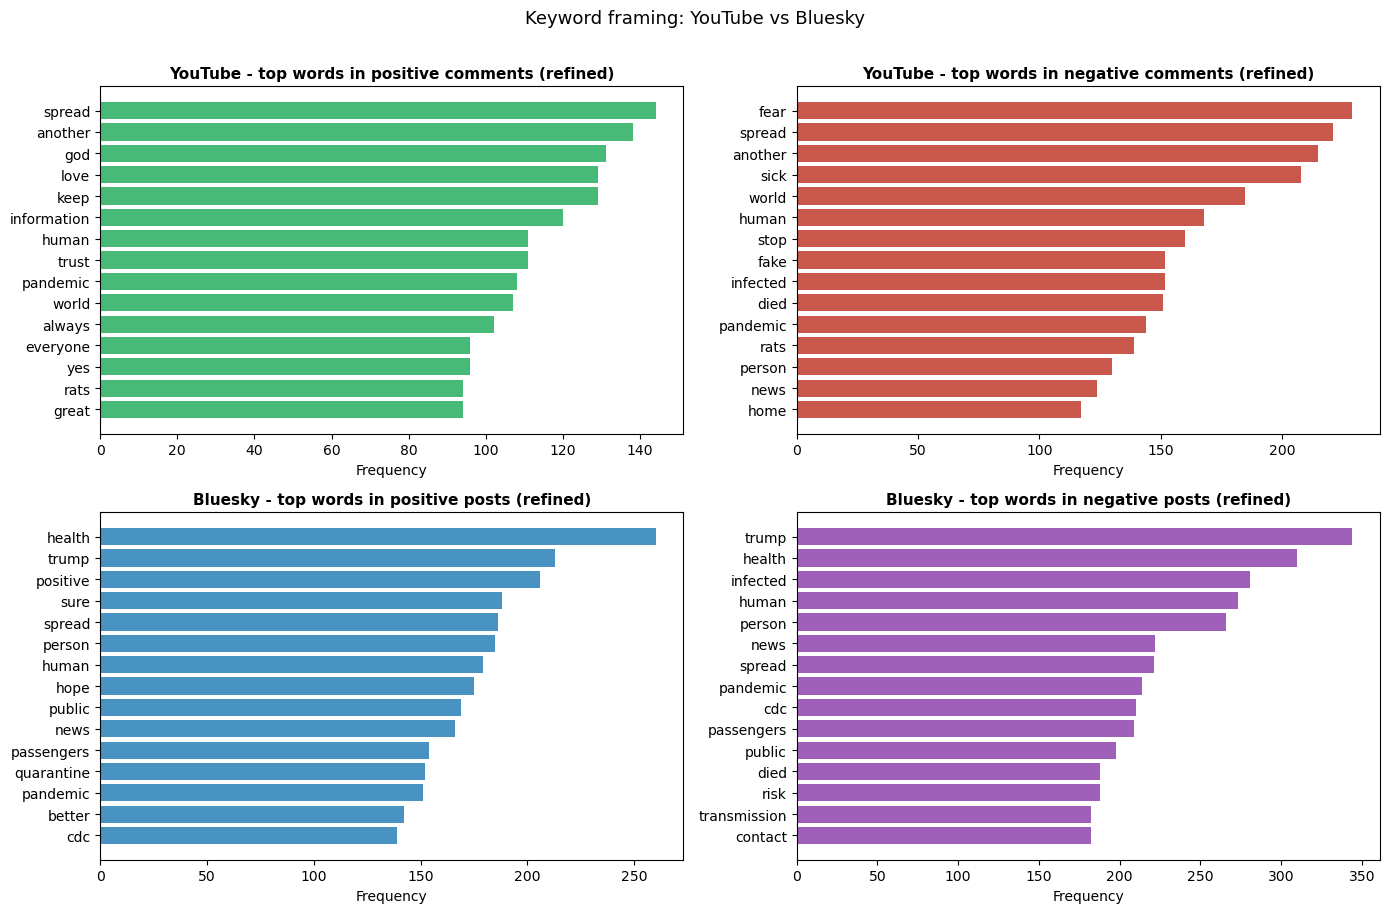

In [27]:
#Expanded stopwords remove generic filler words so only topic-relevant, sentiment-specific language surfaces
extendedStop = allStop | {
    'good', 'well', 'thanks', 'thank', 'please', 'time', 'years', 'year',
    'much', 'really', 'think', 'know', 'people', 'still', 'even', 'many',
    'way', 'say', 'said', 'want', 'need', 'back', 'going', 'now', 'see',
    'got', 'new', 'make', 'something', 'come', 'right', 'never', 'every',
    'let', 'ship', 'cruise', 'outbreak', 'covid'
}

def topYTWordsRefined(df, sentCol, label, topN=15):
    subset = df[df[sentCol] == label]
    tokens = flattenYTTokens(subset['tokens'])
    counts = Counter(t.lower() for t in tokens
                     if t.isalpha() and t.lower() not in extendedStop and len(t) > 2)
    return counts.most_common(topN)

def topBSWordsRefined(df, sentCol, label, topN=15):
    subset = df[df[sentCol] == label]
    tokens = [tok for text in subset['text'].dropna() for tok in tokeniseBS(text)]
    counts = Counter(t for t in tokens
                     if t.isalpha() and t not in extendedStop and len(t) > 2)
    return counts.most_common(topN)

ytPosR = topYTWordsRefined(ytMay, 'vader_label',    'positive')
ytNegR = topYTWordsRefined(ytMay, 'vader_label',    'negative')
bsPosR = topBSWordsRefined(bsDF,  'sentimentLabel', 'positive')
bsNegR = topBSWordsRefined(bsDF,  'sentimentLabel', 'negative')

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
plotHBar(axes[0,0], ytPosR, '#27ae60', 'YouTube - top words in positive comments (refined)')
plotHBar(axes[0,1], ytNegR, '#c0392b', 'YouTube - top words in negative comments (refined)')
plotHBar(axes[1,0], bsPosR, '#2980b9', 'Bluesky - top words in positive posts (refined)')
plotHBar(axes[1,1], bsNegR, '#8e44ad', 'Bluesky - top words in negative posts (refined)')

plt.suptitle('Keyword framing: YouTube vs Bluesky',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('images/keyword_framing_refined.png', dpi=150, bbox_inches='tight')
plt.show()

---
#### NRC Emotion Analysis: YouTube vs Bluesky

In [28]:
#Allows richer cross-platform comparison beyond positive/neutral/negative
from nrclex import NRCLex
import ast

emotionLabels = ['fear', 'trust', 'anger', 'sadness',
                 'joy', 'anticipation', 'disgust', 'surprise']

nrcLexicon = NRCLex('placeholder').__lexicon__

#Parse tokens column from CSV 
def parseTokens(t):
    if isinstance(t, list): return t
    try: return ast.literal_eval(str(t))
    except: return str(t).lower().split()

#Count NRC emotions from an iterable of token lists
def countNRCEmotions(tokenLists):
    counter = Counter({e: 0 for e in emotionLabels})
    for tokens in tokenLists:
        for token in tokens:
            if token in nrcLexicon:
                for emotion in nrcLexicon[token]:
                    if emotion in emotionLabels:
                        counter[emotion] += 1
    return counter

#Tokenise
bsEmotions = countNRCEmotions(bsDF['text'].dropna().apply(tokeniseBS))
ytEmotions = countNRCEmotions(ytMay['tokens'].dropna().apply(parseTokens))

print('Bluesky emotion totals:')
for e, c in sorted(bsEmotions.items(), key=lambda x: -x[1]):
    print('  {}: {}'.format(e, c))
print()
print('YouTube emotion totals:')
for e, c in sorted(ytEmotions.items(), key=lambda x: -x[1]):
    print('  {}: {}'.format(e, c))

Bluesky emotion totals:
  anticipation: 8317
  fear: 8177
  trust: 7570
  sadness: 6226
  disgust: 4389
  anger: 4048
  joy: 3631
  surprise: 3380

YouTube emotion totals:
  fear: 6229
  anticipation: 5335
  trust: 5199
  sadness: 4465
  disgust: 3382
  anger: 3152
  joy: 2893
  surprise: 2052


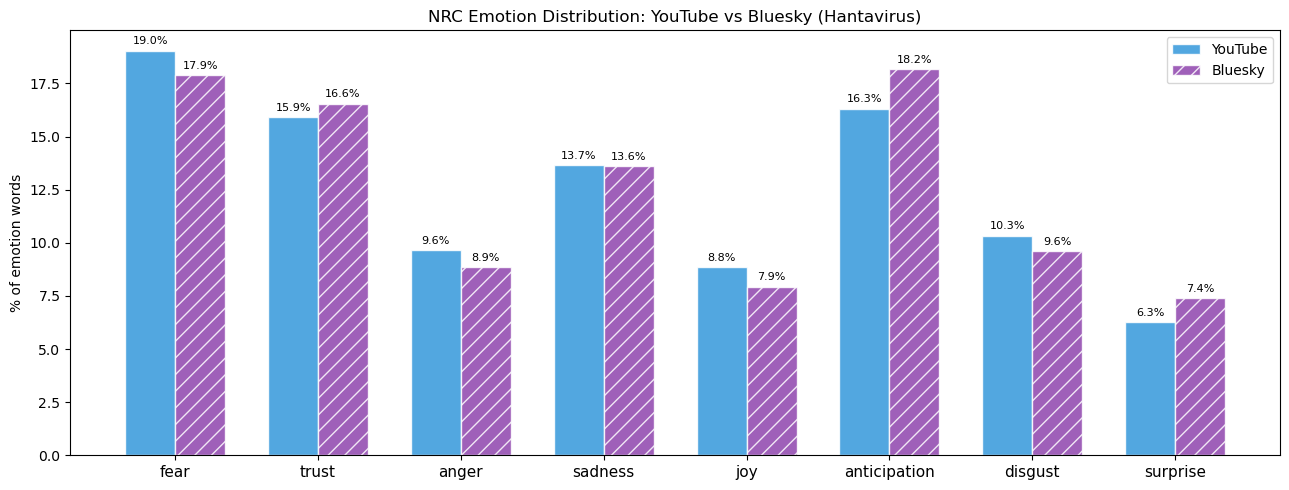

In [29]:
#Normalise to percentages for fair comparison 
bsTotal = sum(bsEmotions.values())
ytTotal = sum(ytEmotions.values())

bsPct = {e: bsEmotions[e] / bsTotal * 100 for e in emotionLabels}
ytPct = {e: ytEmotions[e] / ytTotal * 100 for e in emotionLabels}

#Grouped bar chart
x     = np.arange(len(emotionLabels))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
barsYT = ax.bar(x - width/2, [ytPct[e] for e in emotionLabels], width,
                label='YouTube', color='#3498db', alpha=0.85, edgecolor='white')
barsBS = ax.bar(x + width/2, [bsPct[e] for e in emotionLabels], width,
                label='Bluesky',  color='#8e44ad', alpha=0.85, edgecolor='white', hatch='//')

for bar in list(barsYT) + list(barsBS):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.2,
            '{:.1f}%'.format(h), ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(emotionLabels, fontsize=11)
ax.set_ylabel('% of emotion words')
ax.set_title('NRC Emotion Distribution: YouTube vs Bluesky (Hantavirus)')
ax.legend()
plt.tight_layout()
plt.savefig('images/nrc_emotion_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
#Identify dominant emotion per platform and largest cross-platform differences
dominantYT = max(ytPct, key=ytPct.get)
dominantBS = max(bsPct, key=bsPct.get)

print('Dominant emotion - YouTube : {} ({:.1f}%)'.format(dominantYT, ytPct[dominantYT]))
print('Dominant emotion - Bluesky : {} ({:.1f}%)'.format(dominantBS, bsPct[dominantBS]))

#Emotion gap: which emotions differ most between platforms?
gaps = {e: bsPct[e] - ytPct[e] for e in emotionLabels}
print('\nEmotion gap (Bluesky % - YouTube %) - sorted by magnitude:')
for e, gap in sorted(gaps.items(), key=lambda x: abs(x[1]), reverse=True):
    direction = 'higher on Bluesky' if gap > 0 else 'higher on YouTube'
    print('  {:15s}: {:+.1f}pp ({})'.format(e, gap, direction))

Dominant emotion - YouTube : fear (19.0%)
Dominant emotion - Bluesky : anticipation (18.2%)

Emotion gap (Bluesky % - YouTube %) - sorted by magnitude:
  anticipation   : +1.9pp (higher on Bluesky)
  fear           : -1.2pp (higher on YouTube)
  surprise       : +1.1pp (higher on Bluesky)
  joy            : -0.9pp (higher on YouTube)
  anger          : -0.8pp (higher on YouTube)
  disgust        : -0.7pp (higher on YouTube)
  trust          : +0.7pp (higher on Bluesky)
  sadness        : -0.0pp (higher on YouTube)


---
### Network Visualisation

In [31]:
#The full graph (5478 nodes) is too dense to visualise meaningfully
#Filter to nodes with degree >= 3 to remove leaf nodes and reveal the core structure
coreNodes = [n for n, d in G.degree() if d >= 3]
subG = G.subgraph(coreNodes).copy()

print("Full graph    — Nodes: {}  Edges: {}".format(G.number_of_nodes(), G.number_of_edges()))
print("Core subgraph — Nodes: {}  Edges: {}".format(subG.number_of_nodes(), subG.number_of_edges()))

Full graph    — Nodes: 8755  Edges: 10883
Core subgraph — Nodes: 1442  Edges: 2884


In [32]:
#Compute layout once and reuse for all three network plots
pos = nx.spring_layout(subG, k=0.4, seed=42)

#Node size from Katz centrality — square-root scaling to make differences visible
katzArr  = np.array([subG.nodes[n].get('katz', 0.013) for n in subG.nodes()])
normKatz = (katzArr - katzArr.min()) / (katzArr.max() - katzArr.min())
nodeSizes = (np.sqrt(normKatz) * 300) + 40
nodeSizeDict = {n: s for n, s in zip(subG.nodes(), nodeSizes)}

#Top 15 nodes by Katz centrality for labelling in the graph visualisation
nodeList  = list(subG.nodes())
topIdx    = np.argsort(katzArr)[::-1][:15]
topNodes  = [nodeList[i] for i in topIdx]
labelDict = {
    n: (n.replace('.bsky.social','').replace('.com','').replace('.lol','').replace('.net',''))
    for n in topNodes
}

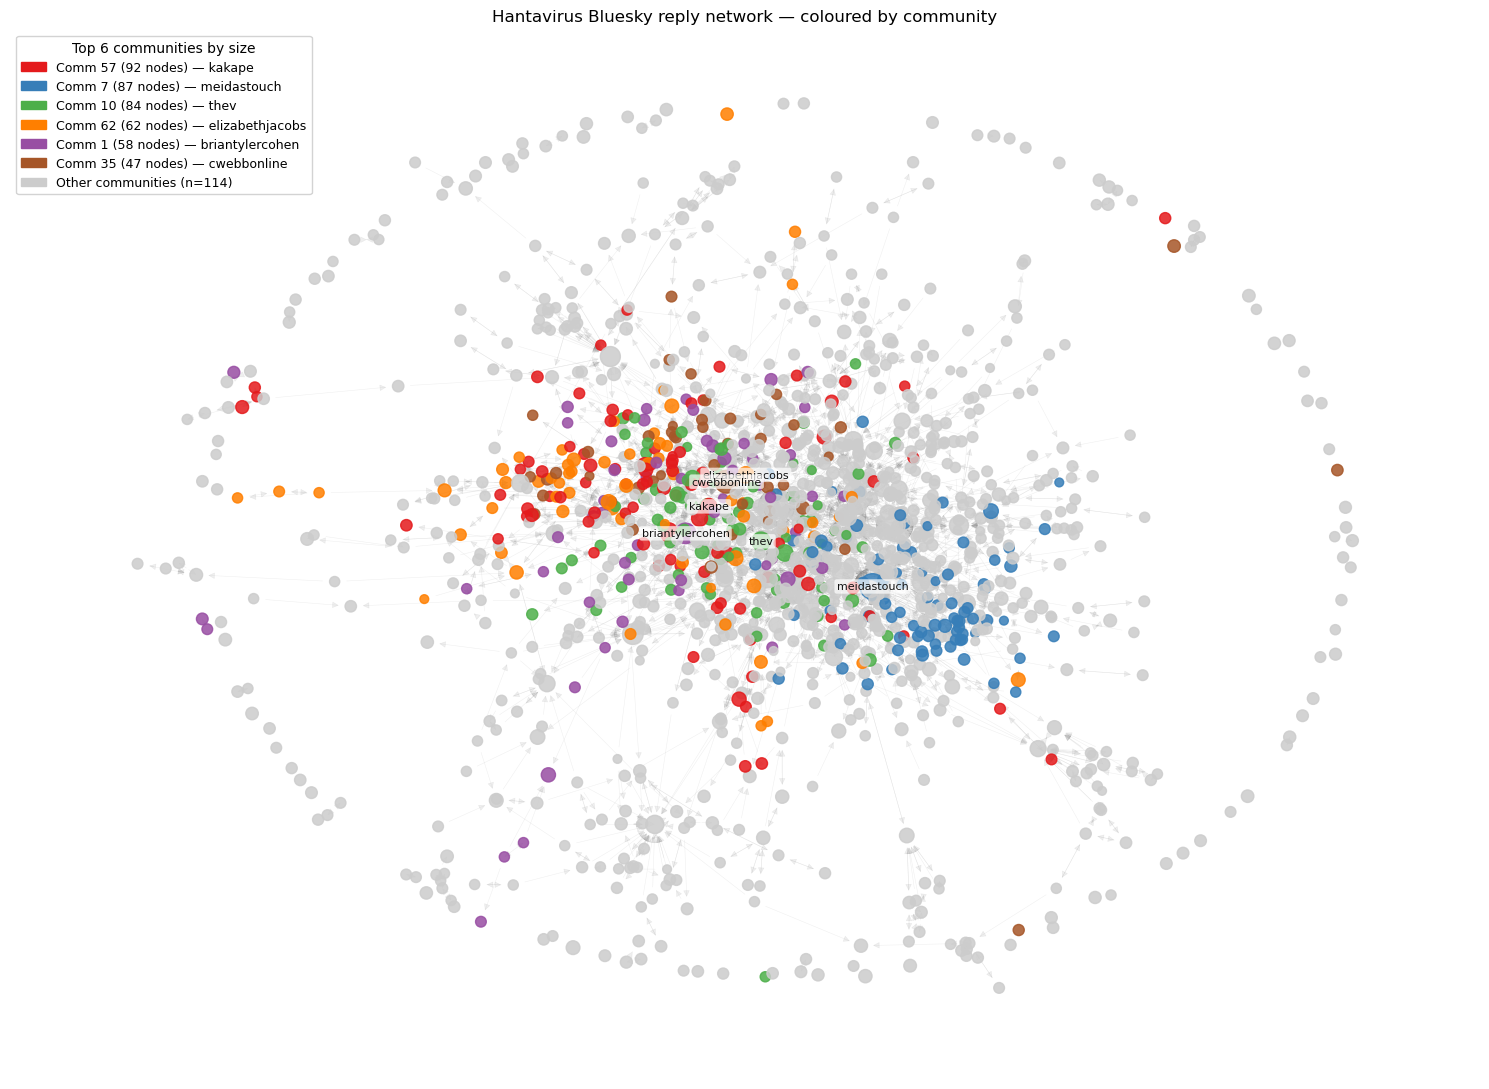

In [33]:
#Plot the core network coloured by Louvain community
commSizes = Counter(subG.nodes[n].get('louvain', 0) for n in subG.nodes())
#Top 6 communities by size get distinct colours
TOP_N = 6
distinctColours = ['#e41a1c', '#377eb8', '#4daf4a', '#ff7f00', '#984ea3', '#a65628']
topNComms = [c for c, _ in commSizes.most_common(TOP_N)]
commColourMap = {c: distinctColours[i] for i, c in enumerate(topNComms)}

#All other communities grey
nodeColours = [
    commColourMap.get(subG.nodes[n].get('louvain', 0), '#cccccc')
    for n in subG.nodes()
]

#For each highlighted community label its most central node
def cleanHandle(n):
    return (n.replace('.bsky.social','').replace('.com','')
             .replace('.lol','').replace('.net','').replace('.org',''))

commLabelDict = {}
for comm in topNComms:
    commNodes = [n for n in subG.nodes() if subG.nodes[n].get('louvain', 0) == comm]
    if commNodes:
        centralNode = max(commNodes, key=lambda n: subG.nodes[n].get('katz', 0))
        commLabelDict[centralNode] = cleanHandle(centralNode)

#Legend 
legendPatches = [
    mpatches.Patch(color=commColourMap[c],
                   label='Comm {} ({} nodes) — {}'.format(
                       c, commSizes[c], commLabelDict.get(
                           max([n for n in subG.nodes() if subG.nodes[n].get('louvain',0)==c],
                               key=lambda n: subG.nodes[n].get('katz',0)),
                           '?')))
    for c in topNComms
]
legendPatches.append(
    mpatches.Patch(color='#cccccc',
                   label='Other communities (n={})'.format(len(commSizes) - TOP_N))
)

plt.figure(figsize=(15, 11))
nx.draw_networkx_edges(subG, pos, alpha=0.12, width=0.4, edge_color='grey')
nx.draw_networkx_nodes(subG, pos, node_color=nodeColours, node_size=nodeSizes, alpha=0.85)
nx.draw_networkx_labels(subG, pos, labels=commLabelDict, font_size=8, font_color='#111',
                        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='none'))
plt.legend(handles=legendPatches, loc='upper left', fontsize=9,
           framealpha=0.85, title='Top {} communities by size'.format(TOP_N), title_fontsize=10)
plt.title('Hantavirus Bluesky reply network — coloured by community')
plt.axis('off')
plt.tight_layout()
plt.savefig('images/network_by_community.png', dpi=150, bbox_inches='tight')
plt.show()

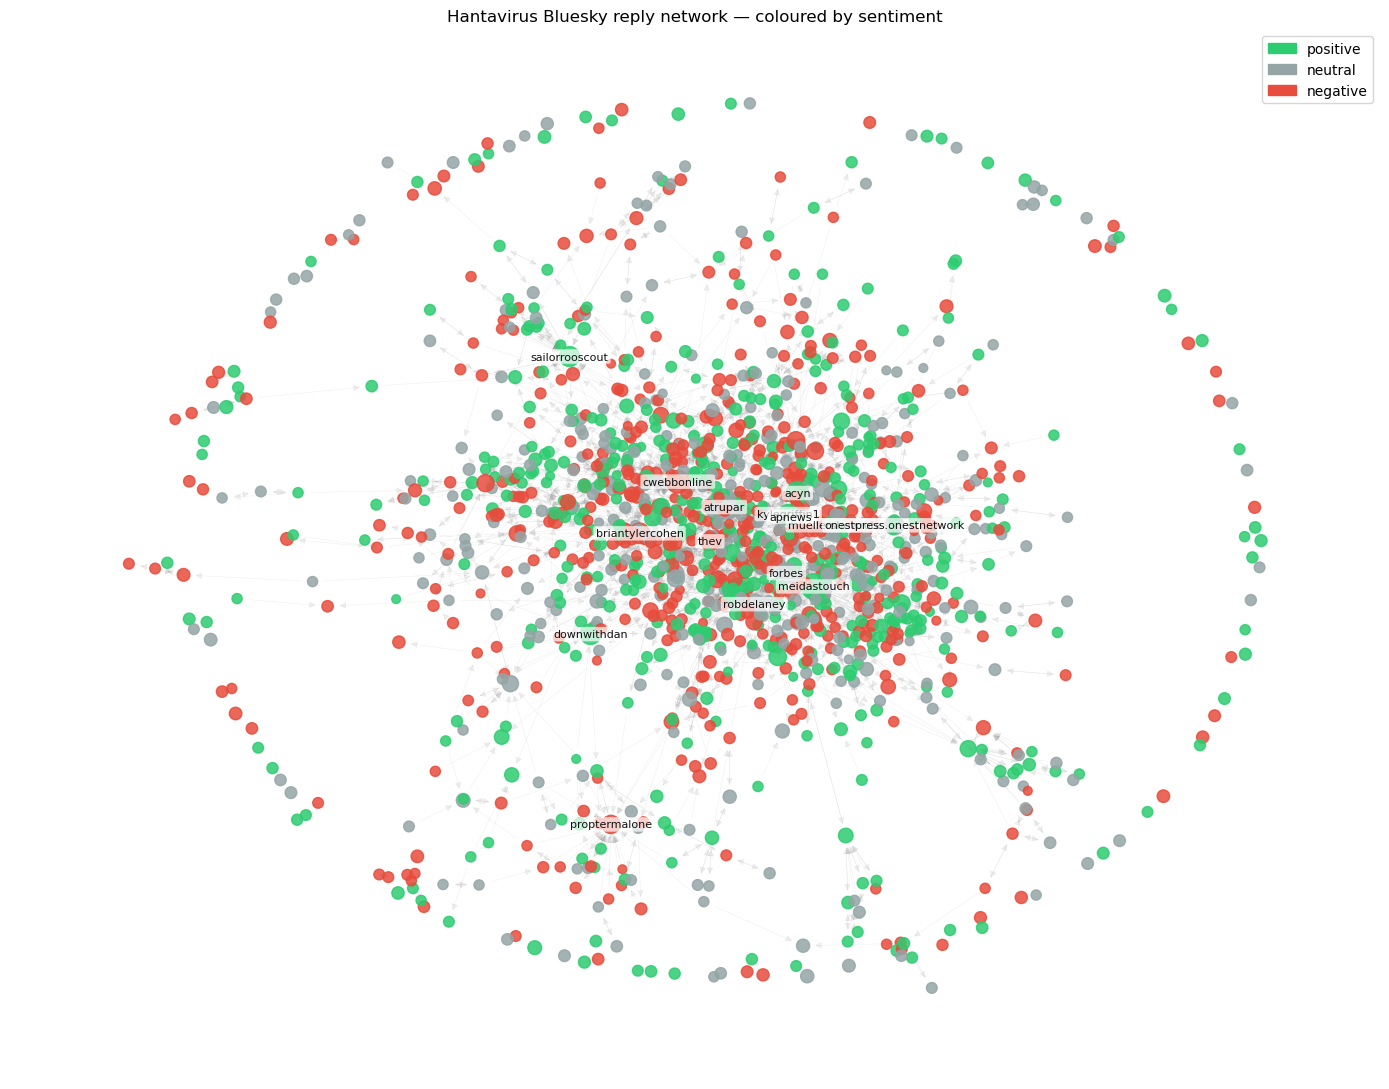

In [34]:
#Plot the same core network coloured by sentiment
sentColours     = {'positive': '#2ecc71', 'neutral': '#95a5a6', 'negative': '#e74c3c'}
nodeColoursSent = [sentColours.get(subG.nodes[n].get('sentimentLabel','neutral'),'#95a5a6')
                   for n in subG.nodes()]
legendPatches   = [mpatches.Patch(color=c, label=l) for l, c in sentColours.items()]

plt.figure(figsize=(14, 11))
nx.draw_networkx_edges(subG, pos, alpha=0.12, width=0.4, edge_color='grey')
nx.draw_networkx_nodes(subG, pos, node_color=nodeColoursSent, node_size=nodeSizes, alpha=0.85)
nx.draw_networkx_labels(subG, pos, labels=labelDict, font_size=8, font_color='#111',
                        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='none'))
plt.legend(handles=legendPatches, loc='upper right', fontsize=10)
plt.title('Hantavirus Bluesky reply network — coloured by sentiment')
plt.axis('off')
plt.tight_layout()
plt.savefig('images/network_by_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

---
### Topic-Enriched Network Visualisation

In [35]:
#Run LDA on Bluesky posts to identify 3 dominant topics
import warnings
warnings.filterwarnings('ignore')
from gensim import corpora
from gensim.models import LdaModel

tweetTok = TweetTokenizer()
lPunct = list(string.punctuation)
lStop = set(stopwords.words('english') + lPunct +
            ['rt', 'via', 'amp', 'hantavirus', 'hanta', 'http', 'https', 'co'])

def tokenisePost(text):
    text = re.sub(r'http\S+|www\S+', '', str(text))
    text = re.sub(r'[^\w\s]', ' ', text)
    return [t for t in tweetTok.tokenize(text.lower())
            if t not in lStop and len(t) > 2 and not t.isdigit()]

bsDF['tokens'] = bsDF['text'].apply(tokenisePost)

#Build LDA corpus
ldaDocs = bsDF['tokens'].tolist()
ldaDict = corpora.Dictionary(ldaDocs)
ldaCorpus = [ldaDict.doc2bow(doc) for doc in ldaDocs]

#Train with 3 topics
ldaModel = LdaModel(ldaCorpus, num_topics=3, id2word=ldaDict, random_state=42, passes=5)

topicNames = {0: 'Political / Health Policy',
              1: 'Cruise Ship Outbreak',
              2: 'General Discussion'}

print('Topics identified:')
for i, t in ldaModel.print_topics():
    print('  Topic {} ({}): {}'.format(i, topicNames[i], t[:100]))


Topics identified:
  Topic 0 (Political / Health Policy): 0.013*"human" + 0.012*"cruise" + 0.011*"ship" + 0.010*"person" + 0.010*"virus" + 0.009*"spread" + 0.
  Topic 1 (Cruise Ship Outbreak): 0.014*"like" + 0.013*"people" + 0.011*"covid" + 0.010*"get" + 0.009*"know" + 0.008*"would" + 0.007*"
  Topic 2 (General Discussion): 0.044*"ship" + 0.043*"cruise" + 0.027*"outbreak" + 0.015*"people" + 0.015*"three" + 0.013*"health" +


In [36]:
#Assign dominant topic per user
def getDominantTopic(bow):
    if not bow:
        return -1
    topics = ldaModel.get_document_topics(bow, minimum_probability=0)
    return max(topics, key=lambda x: x[1])[0]

bsDF['topicId'] = [getDominantTopic(c) for c in ldaCorpus]

#Majority topic per user
userTopicMap = (
    bsDF[bsDF['topicId'] >= 0]
    .groupby('author')['topicId']
    .agg(lambda x: x.value_counts().index[0])
    .to_dict()
)

print('Users with topic assigned: {}'.format(len(userTopicMap)))
topicDist = pd.Series(list(userTopicMap.values())).value_counts().sort_index()
for tid, cnt in topicDist.items():
    print('  {}: {} users'.format(topicNames[tid], cnt))


Users with topic assigned: 8598
  Political / Health Policy: 1934 users
  Cruise Ship Outbreak: 4957 users
  General Discussion: 1707 users


In [37]:
#Add topic attributes to graph nodes
topicColours = {0: '#7F77DD', 1: '#1D9E75', 2: '#EF9F27', -1: '#888780'}

for node in G.nodes():
    t = userTopicMap.get(node, -1)
    G.nodes[node]['topicId']    = int(t)
    G.nodes[node]['topicLabel'] = topicNames.get(t, 'Unknown')

#Filter to core subgraph 
coreNodes = [n for n, d in G.degree() if d >= 3]
subG = G.subgraph(coreNodes).copy()
print('Core subgraph: {} nodes, {} edges'.format(subG.number_of_nodes(), subG.number_of_edges()))

#Top 15 nodes by Katz
topNodes = set(sorted(subG.nodes(), key=lambda n: subG.nodes[n].get('katz', 0), reverse=True)[:15])
print('\nTop 5 influential nodes:')
for n in list(topNodes)[:5]:
    d = subG.nodes[n]
    print('  {} | katz={:.4f} | topic={} | sentiment={}'.format(
        n, d.get('katz',0), d.get('topicLabel','?'), d.get('sentimentLabel','?')))


Core subgraph: 1442 nodes, 2884 edges

Top 5 influential nodes:
  acyn.bsky.social | katz=0.0379 | topic=Cruise Ship Outbreak | sentiment=positive
  robdelaney.bsky.social | katz=0.0275 | topic=Unknown | sentiment=neutral
  thev.bsky.social | katz=0.0215 | topic=Political / Health Policy | sentiment=negative
  proptermalone.bsky.social | katz=0.0201 | topic=Cruise Ship Outbreak | sentiment=negative
  muellershewrote.com | katz=0.0292 | topic=Political / Health Policy | sentiment=positive


Topics inferred from neighbours: 0


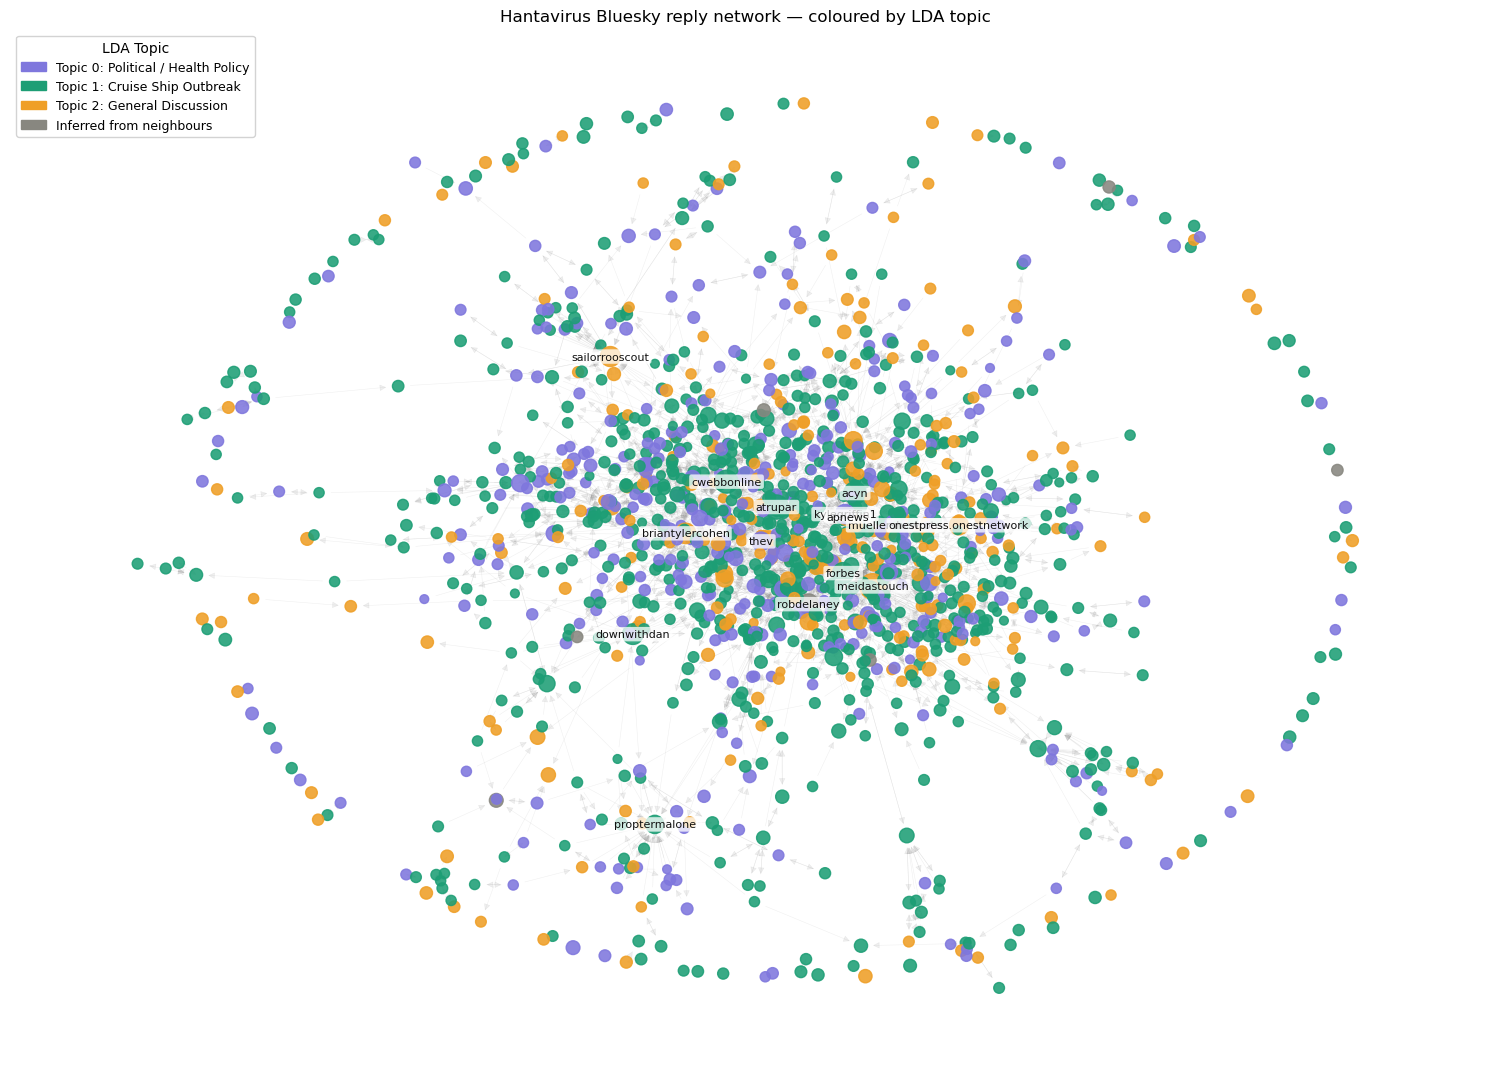

Topics inferred: 0  |  Nodes: 1442  |  Edges: 2884


In [38]:
#Reveals whether influential nodes cluster around particular discussion topics
#Neighbour inference — nodes with no posts get majority topic of their neighbours
inferredCount = 0
for node in subG.nodes():
    if subG.nodes[node].get('topicId', -1) == -1:
        neighbourTopics = [
            subG.nodes[nbr].get('topicId', -1)
            for nbr in subG.neighbors(node)
            if subG.nodes[nbr].get('topicId', -1) >= 0
        ]
        if neighbourTopics:
            inferredTopic = max(set(neighbourTopics), key=neighbourTopics.count)
            subG.nodes[node]['topicId']    = inferredTopic
            subG.nodes[node]['topicLabel'] = topicNames[inferredTopic] + ' (inferred)'
            inferredCount += 1

print('Topics inferred from neighbours: {}'.format(inferredCount))

#Node colours by topic
nodeColoursTopic = [
    topicColours.get(subG.nodes[n].get('topicId', -1), '#888780')
    for n in subG.nodes()
]

#Legend patches
topicLegend = [
    mpatches.Patch(color='#7F77DD', label='Topic 0: Political / Health Policy'),
    mpatches.Patch(color='#1D9E75', label='Topic 1: Cruise Ship Outbreak'),
    mpatches.Patch(color='#EF9F27', label='Topic 2: General Discussion'),
    mpatches.Patch(color='#888780', label='Inferred from neighbours'),
]

plt.figure(figsize=(15, 11))
nx.draw_networkx_edges(subG, pos, alpha=0.12, width=0.4, edge_color='grey')
nx.draw_networkx_nodes(subG, pos, node_color=nodeColoursTopic,
                       node_size=[nodeSizeDict.get(n, 40) for n in subG.nodes()], alpha=0.88)
nx.draw_networkx_labels(subG, pos, labels=labelDict, font_size=8,
                        font_color='#111',
                        bbox=dict(boxstyle='round,pad=0.2', fc='white',
                                  alpha=0.75, ec='none'))
plt.legend(handles=topicLegend, loc='upper left', fontsize=9,
           framealpha=0.85, title='LDA Topic', title_fontsize=10)
plt.title(
    'Hantavirus Bluesky reply network — coloured by LDA topic')

plt.axis('off')
plt.tight_layout()
plt.savefig('images/network_by_topic.png', dpi=150, bbox_inches='tight')
plt.show()
print('Topics inferred: {}  |  Nodes: {}  |  Edges: {}'.format(
    inferredCount, subG.number_of_nodes(), subG.number_of_edges()))

In [39]:
#Save Bluesky sentiment summary
userSentimentDF = bsDF.groupby('author').agg(
    meanCompound=('compound', 'mean'),
    postCount=('compound', 'count'),
    majorityLabel=('sentimentLabel', lambda x: x.value_counts().index[0])
).reset_index()

userSentimentDF.to_csv('Data/bluesky_user_sentiment.csv', index=False)
print("Saved user sentiment to Data/bluesky_user_sentiment.csv")
print("Saved enriched graph to Graphs/HV_sentiment_graph.graphml")

Saved user sentiment to Data/bluesky_user_sentiment.csv
Saved enriched graph to Graphs/HV_sentiment_graph.graphml
